# Predicting Student Dropout and Academic Success

Comparative evaluation of five classification algorithms on a three-class student-outcome
problem, using the *Predict Students' Dropout and Academic Success* dataset from Kaggle.

**Contents**
1. Setup and data loading
2. Exploratory data analysis
3. Preprocessing and stratified split
4. Model definitions
5. Training and evaluation
6. Comparison table
7. Confusion matrix and per-class analysis
8. Persisting models for the Streamlit app

## 1. Setup and data loading

In [1]:
import json
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    matthews_corrcoef, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
TARGET_COLUMN = "Target"
PALETTE = ["#4C6EF5", "#F59F00", "#12B886"]

In [2]:
df = pd.read_csv("../data/dataset.csv")
df.columns = [c.strip() for c in df.columns]

print(f"Shape          : {df.shape}")
print(f"Features       : {df.shape[1] - 1}   (assignment minimum: 12)")
print(f"Instances      : {df.shape[0]}   (assignment minimum: 500)")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
df.head()

Shape          : (4424, 35)
Features       : 34   (assignment minimum: 12)
Instances      : 4424   (assignment minimum: 500)
Missing values : 0
Duplicate rows : 0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

## 2. Exploratory data analysis

### 2.1 Target distribution

The three classes are unevenly represented. `Enrolled` is the minority at ~18%,
which is the class every model will struggle with later.

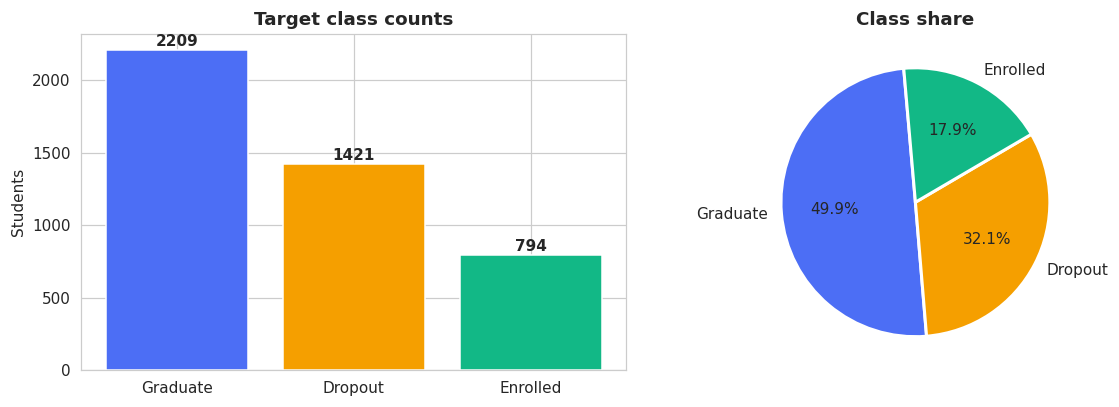

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Imbalance ratio (max/min): 2.78
Accuracy of a model that never predicts 'Enrolled': 82.05%


In [4]:
counts = df[TARGET_COLUMN].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(counts.index, counts.values, color=PALETTE, edgecolor="white")
axes[0].set_title("Target class counts", weight="bold")
axes[0].set_ylabel("Students")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", weight="bold")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=PALETTE, startangle=95,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class share", weight="bold")
plt.tight_layout(); plt.show()

print(counts)
print(f"\nImbalance ratio (max/min): {counts.max() / counts.min():.2f}")
print(f"Accuracy of a model that never predicts 'Enrolled': "
      f"{(counts['Graduate'] + counts['Dropout']) / len(df) * 100:.2f}%")

> The last line is the reason accuracy alone is not a sufficient metric here.
> A model that entirely ignores the minority class still scores ~82%. MCC is the
> metric that exposes this behaviour.

### 2.2 Feature scale disparity

Raw feature ranges differ by orders of magnitude, which motivates selective scaling.

In [5]:
numeric = df.drop(columns=[TARGET_COLUMN])
ranges = pd.DataFrame({
    "min": numeric.min(),
    "max": numeric.max(),
    "mean": numeric.mean(),
    "std": numeric.std(),
}).round(2).sort_values("max", ascending=False)
ranges.head(12)

,min,max,mean,std
Age at enrollment,17.0,70.0,23.27,7.59
Father's occupation,1.0,46.0,7.82,4.86
Curricular units 1st sem (evaluations),0.0,45.0,8.30,4.18
Father's qualification,1.0,34.0,16.46,11.04
Curricular units 2nd sem (evaluations),0.0,33.0,8.06,3.95
Mother's occupation,1.0,32.0,7.32,4.00
Mother's qualification,1.0,29.0,12.32,9.03
Curricular units 1st sem (approved),0.0,26.0,4.71,3.09
Curricular units 1st sem (enrolled),0.0,26.0,6.27,2.48
Curricular units 2nd sem (enrolled),0.0,23.0,6.23,2.20


### 2.3 Feature correlation

The curricular-unit block is heavily inter-correlated. This directly predicts why
Gaussian Naive Bayes will underperform: its conditional-independence assumption is violated.

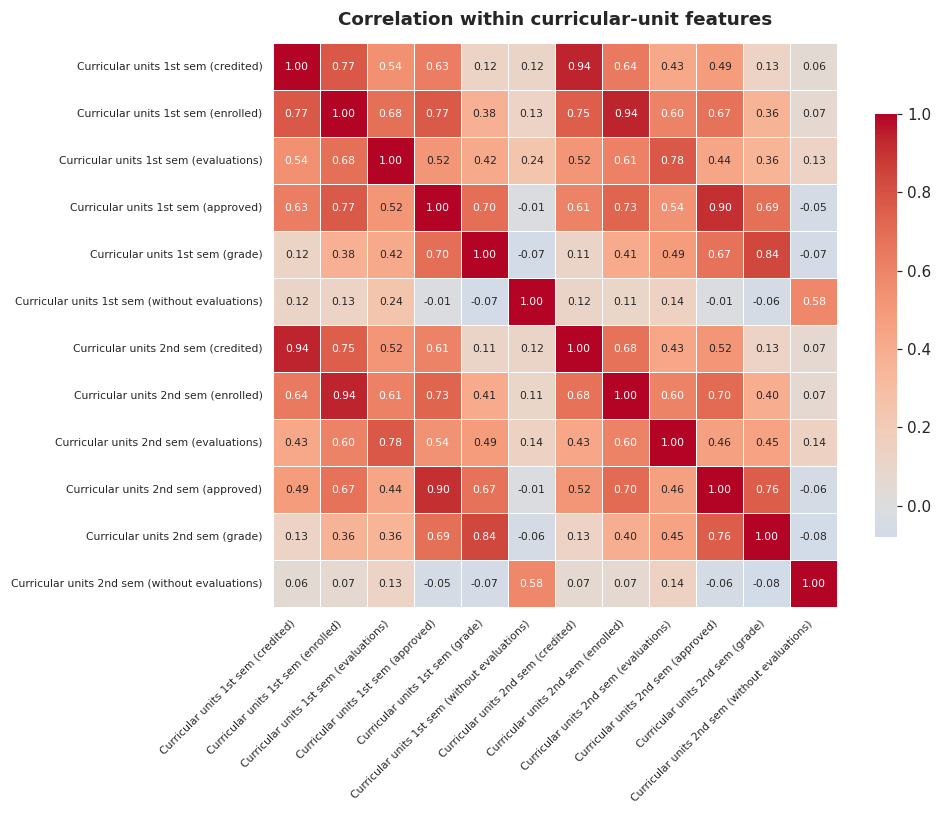

corr(1st sem approved, 2nd sem approved) = 0.9040


In [6]:
curricular = [c for c in df.columns if c.startswith("Curricular")]

plt.figure(figsize=(9.5, 7.5))
sns.heatmap(df[curricular].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.6,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.75})
plt.title("Correlation within curricular-unit features", weight="bold", pad=12)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout(); plt.show()

pair = df["Curricular units 1st sem (approved)"].corr(
       df["Curricular units 2nd sem (approved)"])
print(f"corr(1st sem approved, 2nd sem approved) = {pair:.4f}")

### 2.4 Which features separate the classes?

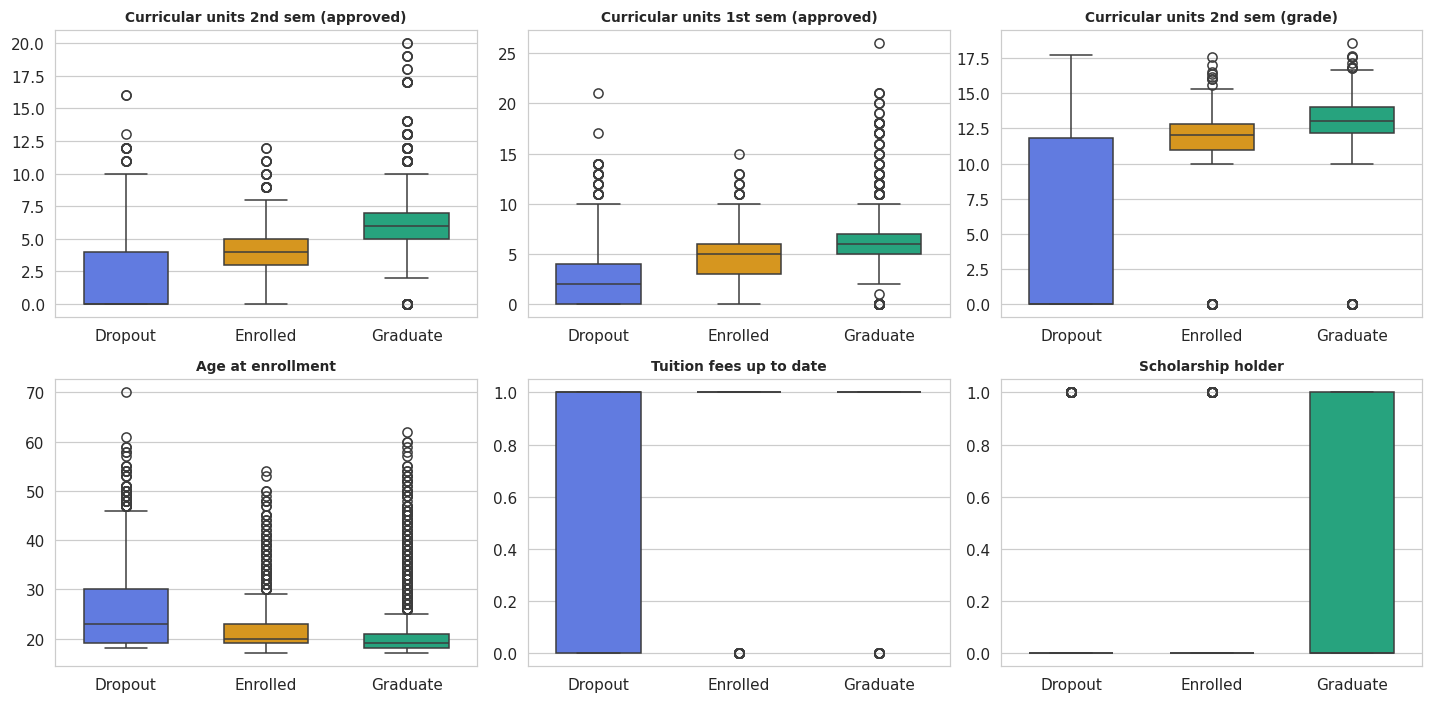

In [7]:
signals = [
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Age at enrollment",
    "Tuition fees up to date",
    "Scholarship holder",
]

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
order = ["Dropout", "Enrolled", "Graduate"]
for ax, column in zip(axes.ravel(), signals):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=column, order=order,
                palette=PALETTE, ax=ax, width=0.6)
    ax.set_title(column, fontsize=9, weight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

In [8]:
# Mean value of each signal per class - the separation, numerically
df.groupby(TARGET_COLUMN)[signals].mean().round(3).T

Target,Dropout,Enrolled,Graduate
Curricular units 2nd sem (approved),1.940,4.058,6.177
Curricular units 1st sem (approved),2.552,4.319,6.232
Curricular units 2nd sem (grade),5.899,11.117,12.697
Age at enrollment,26.069,22.369,21.784
Tuition fees up to date,0.678,0.947,0.987
Scholarship holder,0.094,0.164,0.378


> `Curricular units 2nd sem (approved)` separates the classes most cleanly:
> Dropout students approve roughly 2 units on average, Graduates around 6.
> `Tuition fees up to date` is a strong binary signal — unpaid fees track dropout closely.

## 3. Preprocessing and stratified split

In [9]:
features = df.drop(columns=[TARGET_COLUMN])
encoder = LabelEncoder()
labels = encoder.fit_transform(df[TARGET_COLUMN])

print("Label encoding:")
for i, name in enumerate(encoder.classes_):
    print(f"  {name:<10} -> {i}")

x_train, x_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.20, random_state=RANDOM_STATE, stratify=labels,
)

print(f"\nTrain: {x_train.shape}")
print(f"Test : {x_test.shape}")
print("\nStratification check (proportions preserved):")
print(pd.DataFrame({
    "train": pd.Series(y_train).value_counts(normalize=True).sort_index().round(4),
    "test":  pd.Series(y_test).value_counts(normalize=True).sort_index().round(4),
}).set_index(encoder.classes_))

Label encoding:
  Dropout    -> 0
  Enrolled   -> 1
  Graduate   -> 2

Train: (3539, 34)
Test : (885, 34)

Stratification check (proportions preserved):
           train    test
Dropout   0.3213  0.3209
Enrolled  0.1794  0.1797
Graduate  0.4993  0.4994


In [10]:
# The held-out split is written out for upload into the Streamlit app.
holdout = x_test.copy()
holdout[TARGET_COLUMN] = encoder.inverse_transform(y_test)
holdout.to_csv("../test_data.csv", index=False)
print(f"Wrote ../test_data.csv  ->  {holdout.shape[0]} rows x {holdout.shape[1]} columns")

Wrote ../test_data.csv  ->  885 rows x 35 columns


## 4. Model definitions

Each model is a `Pipeline`, so its preprocessing is serialised together with the
estimator and cannot drift at inference time.

Scaling is applied **selectively**:
- Logistic Regression, kNN, Naive Bayes — distance/magnitude sensitive, so scaled.
- Decision Tree, Random Forest — split on thresholds, invariant to monotone rescaling.

In [11]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=1.0, max_iter=3000, solver="lbfgs",
                                   random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("clf", DecisionTreeClassifier(criterion="entropy", max_depth=8,
                                       min_samples_leaf=12, min_samples_split=20,
                                       random_state=RANDOM_STATE)),
    ]),
    "kNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=15, weights="distance",
                                     metric="minkowski", p=2)),
    ]),
    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GaussianNB(var_smoothing=1e-8)),
    ]),
    "Random Forest (Ensemble)": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=400, max_depth=None,
                                       min_samples_leaf=2, max_features="sqrt",
                                       class_weight="balanced_subsample",
                                       random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

for name, pipe in models.items():
    print(f"{name:<26} {[step for step, _ in pipe.steps]}")

Logistic Regression        ['scaler', 'clf']
Decision Tree              ['clf']
kNN                        ['scaler', 'clf']
Naive Bayes                ['scaler', 'clf']
Random Forest (Ensemble)   ['clf']


### Why the Decision Tree is pruned

An unconstrained tree is fitted below purely to demonstrate the variance problem
that motivated `max_depth=8`.

In [12]:
unpruned = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(x_train, y_train)
pruned = models["Decision Tree"].fit(x_train, y_train)

print("Unpruned tree")
print(f"  depth         : {unpruned.get_depth()}")
print(f"  train accuracy: {accuracy_score(y_train, unpruned.predict(x_train)):.4f}")
print(f"  test accuracy : {accuracy_score(y_test, unpruned.predict(x_test)):.4f}")
print("\nPruned tree (max_depth=8, min_samples_leaf=12)")
print(f"  train accuracy: {accuracy_score(y_train, pruned.predict(x_train)):.4f}")
print(f"  test accuracy : {accuracy_score(y_test, pruned.predict(x_test)):.4f}")

Unpruned tree
  depth         : 30
  train accuracy: 1.0000
  test accuracy : 0.6836

Pruned tree (max_depth=8, min_samples_leaf=12)
  train accuracy: 0.7903
  test accuracy : 0.7458


## 5. Training and evaluation

### Metric averaging for a three-class problem

- **AUC** — one-vs-rest, weighted by class support.
- **Precision / Recall / F1** — weighted averaging, so the score reflects the real
  population rather than letting the 794-row `Enrolled` class dominate a third of it.
- **MCC** — natively multi-class; the most honest single number, because it only
  rises when a model does well on **all three** classes.

In [13]:
def evaluate(model, x, y):
    y_pred = model.predict(x)
    y_proba = model.predict_proba(x)
    return {
        "Accuracy":  accuracy_score(y, y_pred),
        "AUC":       roc_auc_score(y, y_proba, multi_class="ovr", average="weighted"),
        "Precision": precision_score(y, y_pred, average="weighted", zero_division=0),
        "Recall":    recall_score(y, y_pred, average="weighted", zero_division=0),
        "F1":        f1_score(y, y_pred, average="weighted", zero_division=0),
        "MCC":       matthews_corrcoef(y, y_pred),
    }

In [14]:
results, diagnostics = {}, {}

for name, model in models.items():
    model.fit(x_train, y_train)
    scores = evaluate(model, x_test, y_test)
    results[name] = scores

    cv = cross_val_score(model, x_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    train_acc = accuracy_score(y_train, model.predict(x_train))
    diagnostics[name] = {
        "train_accuracy": train_acc,
        "test_accuracy": scores["Accuracy"],
        "overfit_gap": train_acc - scores["Accuracy"],
        "cv_mean": cv.mean(),
        "cv_std": cv.std(),
        "per_class_recall": recall_score(y_test, model.predict(x_test),
                                         average=None, zero_division=0),
    }

    print(f"\n{name}")
    print("-" * len(name))
    for metric, value in scores.items():
        print(f"  {metric:<10} {value:.4f}")
    print(f"  CV(5)      {cv.mean():.4f} +/- {cv.std():.4f}")
    print(f"  Train acc  {train_acc:.4f}  (gap {train_acc - scores['Accuracy']:+.4f})")


Logistic Regression
-------------------
  Accuracy   0.7582
  AUC        0.8980
  Precision  0.7401
  Recall     0.7582
  F1         0.7432
  MCC        0.5977
  CV(5)      0.7666 +/- 0.0108
  Train acc  0.7765  (gap +0.0183)

Decision Tree
-------------
  Accuracy   0.7458
  AUC        0.8721
  Precision  0.7353
  Recall     0.7458
  F1         0.7348
  MCC        0.5781
  CV(5)      0.7330 +/- 0.0123
  Train acc  0.7903  (gap +0.0446)



kNN
---
  Accuracy   0.7119
  AUC        0.8457
  Precision  0.7017
  Recall     0.7119
  F1         0.6839
  MCC        0.5209
  CV(5)      0.7143 +/- 0.0143
  Train acc  1.0000  (gap +0.2881)

Naive Bayes
-----------
  Accuracy   0.6667
  AUC        0.8133
  Precision  0.6467
  Recall     0.6667
  F1         0.6527
  MCC        0.4431
  CV(5)      0.6815 +/- 0.0122
  Train acc  0.6861  (gap +0.0194)



Random Forest (Ensemble)
------------------------
  Accuracy   0.7695
  AUC        0.9077
  Precision  0.7674
  Recall     0.7695
  F1         0.7663
  MCC        0.6214
  CV(5)      0.7742 +/- 0.0072
  Train acc  0.9768  (gap +0.2073)


## 6. Comparison table

In [15]:
comparison = pd.DataFrame(results).T[
    ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]
].round(4)

display(comparison.style.format("{:.4f}")
        .highlight_max(axis=0, color="#D3F9D8")
        .set_caption("Model comparison on the 885-row held-out test set"))

winner = comparison["MCC"].idxmax()
print(f"Best by MCC : {winner}  ({comparison.loc[winner, 'MCC']:.4f})")
print(f"Best by AUC : {comparison['AUC'].idxmax()}")
print(f"Best by F1  : {comparison['F1'].idxmax()}")

,Accuracy,AUC,Precision,Recall,F1,MCC
Logistic Regression,0.7582,0.8980,0.7401,0.7582,0.7432,0.5977
Decision Tree,0.7458,0.8721,0.7353,0.7458,0.7348,0.5781
kNN,0.7119,0.8457,0.7017,0.7119,0.6839,0.5209
Naive Bayes,0.6667,0.8133,0.6467,0.6667,0.6527,0.4431
Random Forest (Ensemble),0.7695,0.9077,0.7674,0.7695,0.7663,0.6214


Best by MCC : Random Forest (Ensemble)  (0.6214)
Best by AUC : Random Forest (Ensemble)
Best by F1  : Random Forest (Ensemble)


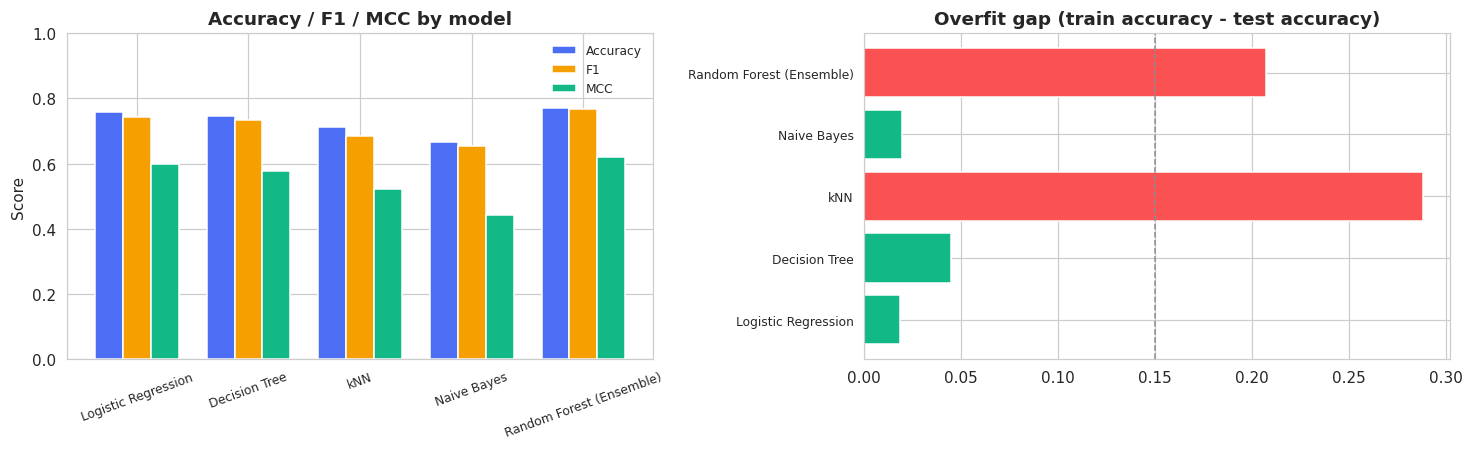

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))

comparison[["Accuracy", "F1", "MCC"]].plot(
    kind="bar", ax=axes[0], color=PALETTE, width=0.75, edgecolor="white")
axes[0].set_title("Accuracy / F1 / MCC by model", weight="bold")
axes[0].set_ylabel("Score"); axes[0].set_ylim(0, 1)
axes[0].legend(frameon=False, fontsize=8)
axes[0].tick_params(axis="x", rotation=20, labelsize=8)

gaps = pd.Series({k: v["overfit_gap"] for k, v in diagnostics.items()})
colours = ["#FA5252" if g > 0.15 else "#12B886" for g in gaps]
axes[1].barh(gaps.index, gaps.values, color=colours, edgecolor="white")
axes[1].set_title("Overfit gap (train accuracy - test accuracy)", weight="bold")
axes[1].axvline(0.15, ls="--", lw=1, color="#868E96")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout(); plt.show()

In [17]:
# Diagnostics behind the written observations
diag_table = pd.DataFrame({
    name: {
        "Train Acc": v["train_accuracy"],
        "Test Acc": v["test_accuracy"],
        "Overfit gap": v["overfit_gap"],
        "CV(5) mean": v["cv_mean"],
        "CV(5) std": v["cv_std"],
        "Recall: Dropout": v["per_class_recall"][0],
        "Recall: Enrolled": v["per_class_recall"][1],
        "Recall: Graduate": v["per_class_recall"][2],
    } for name, v in diagnostics.items()
}).T.round(4)
diag_table

,Train Acc,Test Acc,Overfit gap,CV(5) mean,CV(5) std,Recall: Dropout,Recall: Enrolled,Recall: Graduate
Logistic Regression,0.7765,0.7582,0.0183,0.7666,0.0108,0.7500,0.3270,0.9186
Decision Tree,0.7903,0.7458,0.0446,0.7330,0.0123,0.6831,0.3836,0.9163
kNN,1.0000,0.7119,0.2881,0.7143,0.0143,0.6197,0.2138,0.9502
Naive Bayes,0.6861,0.6667,0.0194,0.6815,0.0122,0.6549,0.2138,0.8371
Random Forest (Ensemble),0.9768,0.7695,0.2073,0.7742,0.0072,0.7289,0.4843,0.8982


> Two patterns stand out:
> - **kNN** has a train accuracy of exactly 1.0000 — an artefact of `weights='distance'`,
>   which makes every training point its own zero-distance neighbour. Its +0.288 gap is
>   the largest in the study.
> - **`Enrolled` recall** is under 0.50 for every model. Random Forest's 0.484 is more
>   than double kNN's and Naive Bayes' 0.214, and that gap is what wins it the MCC column.

## 7. Confusion matrices and per-class analysis

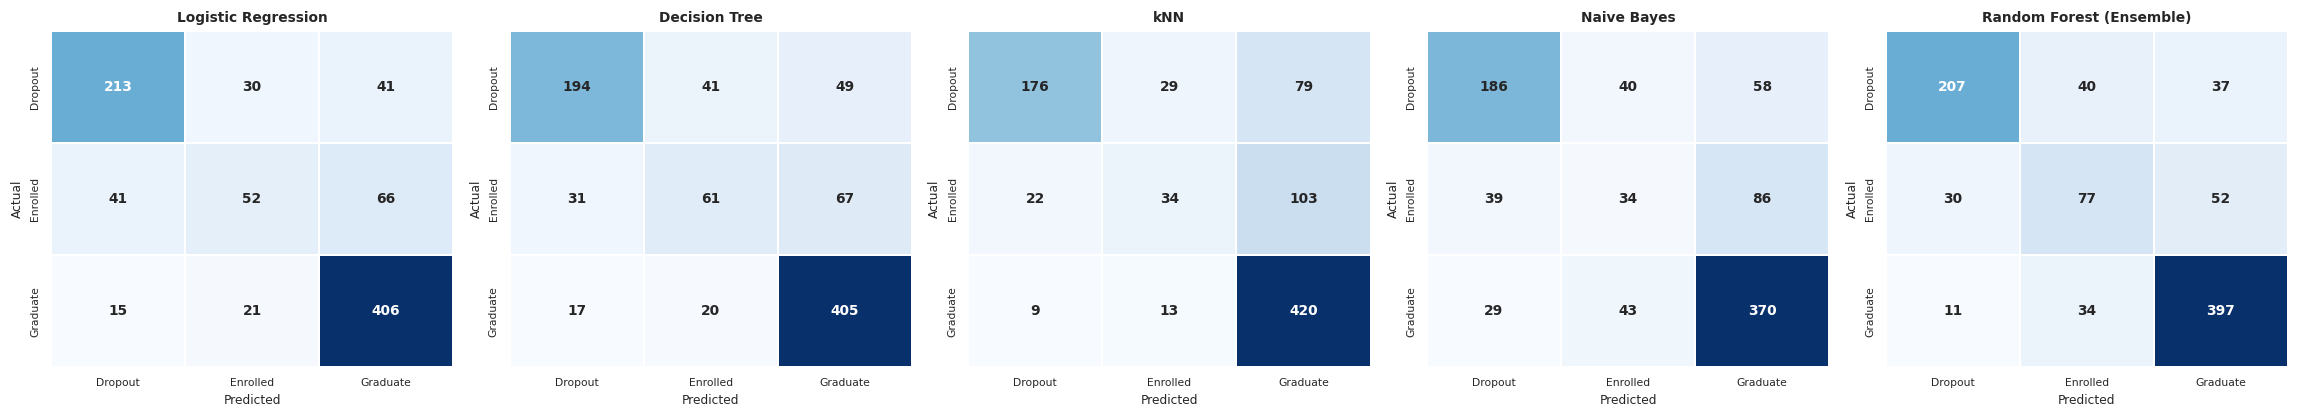

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(21, 3.9))

for ax, (name, model) in zip(axes, models.items()):
    matrix = confusion_matrix(y_test, model.predict(x_test))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=encoder.classes_, yticklabels=encoder.classes_,
                linewidths=1, linecolor="white", ax=ax,
                annot_kws={"size": 9, "weight": "bold"})
    ax.set_title(name, fontsize=9, weight="bold")
    ax.set_xlabel("Predicted", fontsize=8); ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout(); plt.show()

In [19]:
best_model = models[winner]
y_pred_best = best_model.predict(x_test)

print(f"Classification report - {winner}\n")
print(classification_report(y_test, y_pred_best,
                            target_names=encoder.classes_, digits=4, zero_division=0))

Classification report - Random Forest (Ensemble)

              precision    recall  f1-score   support

     Dropout     0.8347    0.7289    0.7782       284
    Enrolled     0.5099    0.4843    0.4968       159
    Graduate     0.8169    0.8982    0.8556       442

    accuracy                         0.7695       885
   macro avg     0.7205    0.7038    0.7102       885
weighted avg     0.7674    0.7695    0.7663       885



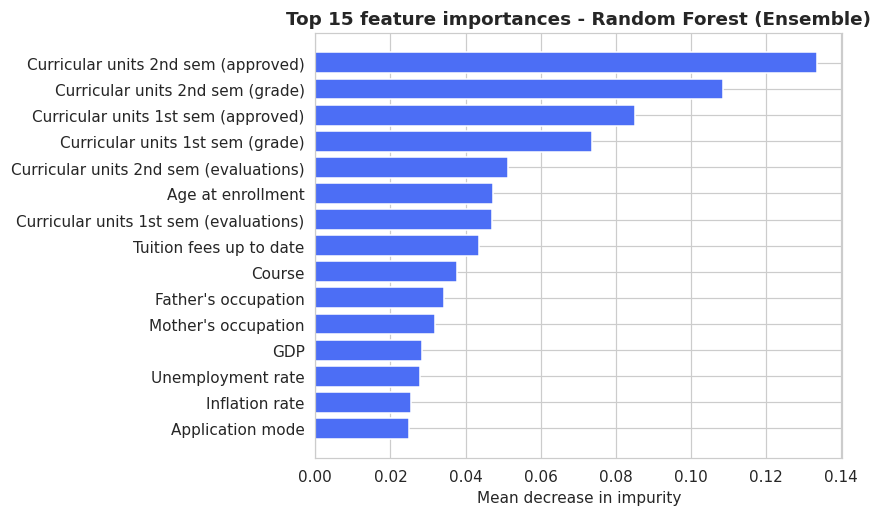

Curricular units 2nd sem (approved)       0.1335
Curricular units 2nd sem (grade)          0.1084
Curricular units 1st sem (approved)       0.0851
Curricular units 1st sem (grade)          0.0737
Curricular units 2nd sem (evaluations)    0.0514
Age at enrollment                         0.0474
Curricular units 1st sem (evaluations)    0.0470
Tuition fees up to date                   0.0436
Course                                    0.0376
Father's occupation                       0.0343
Mother's occupation                       0.0320
GDP                                       0.0285
Unemployment rate                         0.0280
Inflation rate                            0.0256
Application mode                          0.0251
dtype: float64

In [20]:
# Which features does the winning ensemble actually rely on?
importances = pd.Series(
    best_model.named_steps["clf"].feature_importances_, index=x_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 4.8))
plt.barh(importances.index[::-1], importances.values[::-1],
         color="#4C6EF5", edgecolor="white")
plt.title(f"Top 15 feature importances - {winner}", weight="bold")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout(); plt.show()

importances.round(4)

> Second-semester approvals and grades dominate, followed by first-semester results
> and `Tuition fees up to date`. Demographic and macroeconomic features contribute
> comparatively little — outcome is driven mainly by early academic performance and
> financial standing.

## 8. Persisting models for the Streamlit app

In [21]:
os.makedirs(".", exist_ok=True)

for name, model in models.items():
    filename = name.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".pkl"
    joblib.dump(model, filename, compress=3)
    print(f"saved {filename}")

joblib.dump(encoder, "label_encoder.pkl")
joblib.dump(list(x_train.columns), "feature_names.pkl")
comparison.to_csv("comparison_table.csv")

print("\nArtifacts written. The Streamlit app (../app.py) loads these at start-up.")

saved logistic_regression.pkl
saved decision_tree.pkl
saved knn.pkl
saved naive_bayes.pkl


saved random_forest_ensemble.pkl

Artifacts written. The Streamlit app (../app.py) loads these at start-up.


## Conclusion

| Rank | Model | MCC | Note |
|---|---|---|---|
| 1 | **Random Forest (Ensemble)** | **0.6214** | Wins all six metrics; only model with usable minority-class recall |
| 2 | Logistic Regression | 0.5977 | 96% of the winner's MCC, fully interpretable, negligible overfitting |
| 3 | Decision Tree | 0.5781 | Readable decision paths; higher variance than the forest |
| 4 | kNN | 0.5209 | Distance concentration in 34 dimensions |
| 5 | Naive Bayes | 0.4431 | Independence assumption violated by correlated curricular features |

**Overall winner: Random Forest (Ensemble).**

The limiting factor across every model is the `Enrolled` class, where the best recall
achieved is 0.484. That class is a *censored* observation — "has not graduated yet"
rather than a settled outcome — so its feature profile genuinely overlaps both other
classes. A survival-analysis formulation with time-to-event data would suit this
problem better than any of the five classifiers evaluated here.

---
